In [1]:
pip install torch

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [4]:
kaggle_df = pd.read_csv('/content/drive/MyDrive/thesis/kaggle/final/kaggle_df.csv')

kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     1000 non-null   object 
 1   Display_Name                 1000 non-null   object 
 2   Gender                       1000 non-null   object 
 3   notebook_url                 1000 non-null   object 
 4   code_location                1000 non-null   object 
 5   labels                       1000 non-null   object 
 6   top_labels                   1000 non-null   object 
 7   code_sections                1000 non-null   object 
 8   markdown_sections            1000 non-null   object 
 9   all_sections                 1000 non-null   object 
 10  only_code_in_code_sections   1000 non-null   object 
 11  number_of_lines              1000 non-null   float64
 12  names_set                    1000 non-null   object 
 13  num_of_sections    

In [5]:
kaggle_df.drop_duplicates(subset=['only_code_in_code_sections'], inplace=True)

kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     999 non-null    object 
 1   Display_Name                 999 non-null    object 
 2   Gender                       999 non-null    object 
 3   notebook_url                 999 non-null    object 
 4   code_location                999 non-null    object 
 5   labels                       999 non-null    object 
 6   top_labels                   999 non-null    object 
 7   code_sections                999 non-null    object 
 8   markdown_sections            999 non-null    object 
 9   all_sections                 999 non-null    object 
 10  only_code_in_code_sections   999 non-null    object 
 11  number_of_lines              999 non-null    float64
 12  names_set                    999 non-null    object 
 13  num_of_sections          

In [6]:
kaggle_df.Gender.value_counts()

,count
Gender,
male,564
female,435


In [7]:
kaggle_df.describe()

,number_of_lines,num_of_sections,token_count,variables_count,function_count,loop_count,condition_count,single_line_comment_density,function_density,loop_density,condition_density,comment_tokens_density,avg_var_name_length,comment_to_code_ratio,avg_func_length,code_to_markdown_ratio,avg_markdown_lines_length,markdown_sentiment
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,216.792793,23.531532,272.540541,121.866867,4.977978,6.716717,4.383383,0.107532,0.013926,0.023318,0.012729,0.174116,7.406865,4.021132,11.324837,497.786967,2.788292,0.120859
std,237.459812,25.783179,297.021480,89.071965,8.864574,9.743341,9.683165,0.102022,0.018750,0.027889,0.023138,0.175555,1.133259,113.080801,14.407308,1647.924114,3.339554,0.187629
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000045,0.000000,0.000280,0.000000,-0.919300
25%,75.500000,11.000000,147.000000,59.500000,0.000000,1.000000,0.000000,0.030419,0.000000,0.007463,0.000000,0.027988,6.660737,0.024245,0.000000,2.127067,1.000000,0.000000
50%,149.000000,19.000000,229.000000,100.000000,1.000000,4.000000,1.000000,0.081967,0.006969,0.016949,0.005587,0.125874,7.423611,0.152684,7.733333,6.838081,1.857143,0.062878
75%,267.000000,30.000000,335.000000,165.500000,6.000000,8.000000,5.000000,0.150067,0.021787,0.031402,0.018999,0.264690,8.062746,0.506117,17.246678,42.659779,3.825758,0.208990
max,2220.000000,629.000000,6143.000000,754.000000,88.000000,120.000000,120.000000,0.825000,0.147404,0.481928,0.481928,0.811765,17.230216,3574.500000,99.500000,22501.500000,47.000000,0.967450


In [8]:
def concatenate_code_sections(row, unique_char):
    code_list = eval(row)
    concatenated_code = unique_char.join(code_list)
    return concatenated_code

kaggle_df['parsed_code'] = kaggle_df['only_code_in_code_sections'].apply(concatenate_code_sections, unique_char=' ')

In [9]:
X=kaggle_df.drop('Gender',axis=1)
Y=kaggle_df.Gender

In [10]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.parsed_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [11]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [12]:
enc = LabelEncoder()
y_train = enc.fit_transform(y_train)
y_valid = enc.transform(y_valid)
y_test = enc.transform(y_test)

In [13]:
num_labels = len(enc.classes_)
num_labels

2

In [15]:
llm_df = pd.read_csv('/content/Gender_Prediction_Results.csv')

In [18]:
y_test_llm = enc.transform(llm_df.gender_prediction)

              precision    recall  f1-score   support

      female       0.30      0.08      0.13        87
        male       0.55      0.86      0.67       113

    accuracy                           0.52       200
   macro avg       0.43      0.47      0.40       200
weighted avg       0.44      0.52      0.43       200

f1_score_macro :  0.39811912225705326
f1_score_weighted :  0.4333291536050157


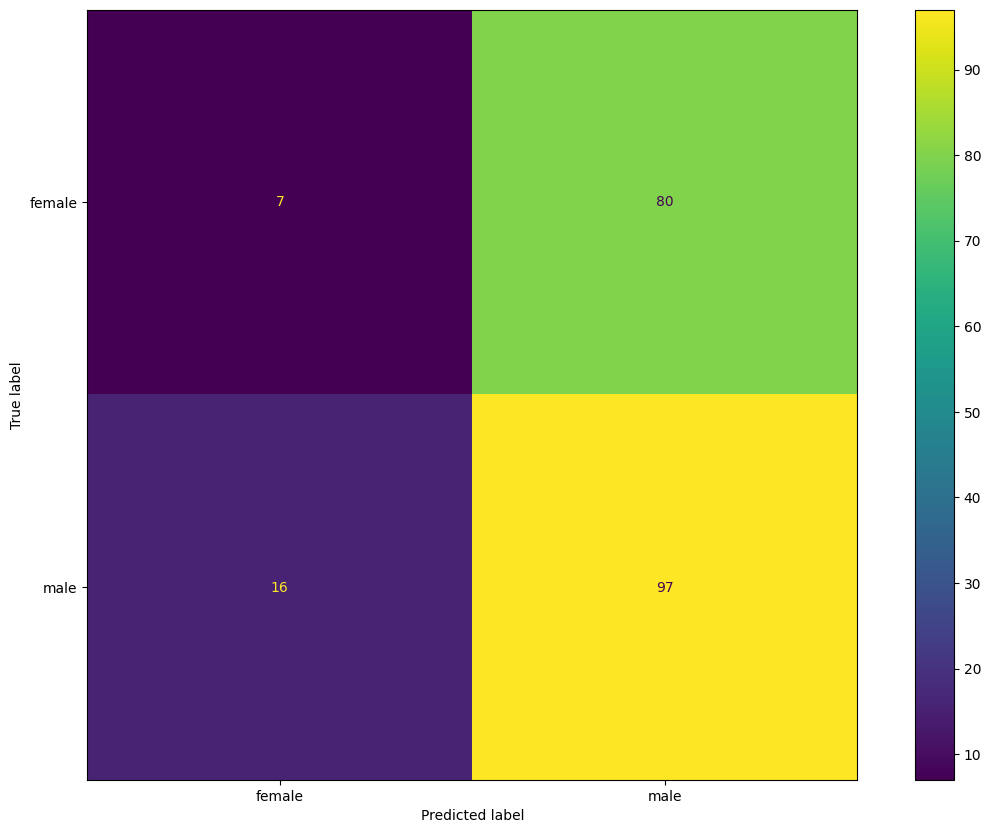

In [19]:
print(classification_report(y_test, y_test_llm, target_names=enc.classes_.tolist()))

print("f1_score_macro : ",f1_score(y_test, y_test_llm, average='macro'))
print("f1_score_weighted : ",f1_score(y_test, y_test_llm, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_llm), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()